# Predictive Likelihood Comparison

This notebook reports the paired one-step-ahead predictive log-likelihood comparison across the four main 400-timestamp windows.

The comparison uses the common q160-update/q300-evaluation runs and the five paired seeds. Positive Rough-SABR minus Markovian values favour the rough-memory filter.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def find_project_root(start=None):
    here = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing src/ and notebooks/.")


def project_relative(path):
    path = Path(path)
    try:
        return path.relative_to(PROJECT_ROOT)
    except ValueError:
        return path


PROJECT_ROOT = find_project_root()
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
COMMON_EVAL_ROOT = OUTPUTS_DIR / "common_eval_q160_eval300"
NONOVERLAP_ROOT = OUTPUTS_DIR / "nonoverlap_q160_eval300"

ANALYSIS_DIR = OUTPUTS_DIR / "comparisons" / "predictive_likelihood"
FIGURE_DIR = ANALYSIS_DIR / "figures"
TABLE_DIR = ANALYSIS_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [123, 456, 789, 101112, 131415]
HAC_LAG = 5

WINDOWS = [
    {
        "key": "w0_400",
        "label": "0-399",
        "base": COMMON_EVAL_ROOT,
        "window_start": 0,
        "markovian_pattern": "normal_400ts_q160_eval300_seed{seed}",
        "rough_pattern": "rough_400ts_q160_eval300_seed{seed}",
    },
    {
        "key": "w401_800",
        "label": "400-799",
        "base": NONOVERLAP_ROOT / "w401_800",
        "window_start": 400,
        "markovian_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
    {
        "key": "w801_1200",
        "label": "800-1199",
        "base": NONOVERLAP_ROOT / "w801_1200",
        "window_start": 800,
        "markovian_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
    {
        "key": "w1201_1600",
        "label": "1200-1599",
        "base": NONOVERLAP_ROOT / "w1201_1600",
        "window_start": 1200,
        "markovian_pattern": "normal_sabr_no_A_RW_seed{seed}",
        "rough_pattern": "rough_sabr_logU0_seed{seed}",
    },
]
WINDOW_ORDER = [window["key"] for window in WINDOWS]
WINDOW_LABELS = {window["key"]: window["label"] for window in WINDOWS}
PREDICTIVE_SCORE_FILE = "predictive_loglikelihood_eval.csv"

## Run Inventory

Each window uses the same five seeds for the Markovian benchmark and the Rough-SABR filter.

In [3]:
inventory_rows = []
for window in WINDOWS:
    for seed in SEEDS:
        for model, pattern in [
            ("Markovian", window["markovian_pattern"]),
            ("Rough-SABR", window["rough_pattern"]),
        ]:
            run_dir = window["base"] / pattern.format(seed=seed)
            inventory_rows.append(
                {
                    "window_key": window["key"],
                    "window": window["label"],
                    "window_start": window["window_start"],
                    "model": model,
                    "seed": seed,
                    "run_dir": run_dir,
                    "score_file_exists": (run_dir / PREDICTIVE_SCORE_FILE).exists(),
                }
            )

inventory = pd.DataFrame(inventory_rows)
missing = inventory.loc[~inventory["score_file_exists"], ["window", "model", "seed", "run_dir"]]
if not missing.empty:
    display(missing.assign(run_dir=lambda d: d["run_dir"].map(project_relative)))
    raise FileNotFoundError("Missing predictive log-likelihood files.")

inventory["window_key"] = pd.Categorical(inventory["window_key"], categories=WINDOW_ORDER, ordered=True)
inventory_summary = (
    inventory.groupby(["window_key", "window", "model"], observed=True)
    .agg(seeds=("seed", "nunique"), runs=("run_dir", "size"))
    .reset_index()
    .drop(columns="window_key")
)
inventory.assign(run_dir=lambda d: d["run_dir"].map(project_relative)).to_csv(
    TABLE_DIR / "predictive_likelihood_run_inventory.csv",
    index=False,
)
display(inventory_summary)

,window,model,seeds,runs
0,0-399,Markovian,5,5
1,0-399,Rough-SABR,5,5
2,400-799,Markovian,5,5
3,400-799,Rough-SABR,5,5
4,800-1199,Markovian,5,5
5,800-1199,Rough-SABR,5,5
6,1200-1599,Markovian,5,5
7,1200-1599,Rough-SABR,5,5


## Load Paired Predictive Scores

The paired table keeps only timestamps available for both models within the same window and seed.

In [4]:
SCORE_COLUMNS = [
    "capture_time_utc",
    "t_index",
    "n_quotes",
    "n_update_quotes",
    "log_predictive_likelihood",
    "avg_log_predictive_likelihood_per_quote",
    "eval_n_options",
    "eval_n_priced",
]


def load_scores(path):
    df = pd.read_csv(path, usecols=lambda col: col in SCORE_COLUMNS)
    missing = sorted(set(SCORE_COLUMNS) - set(df.columns))
    if missing:
        raise ValueError(f"{project_relative(path)} is missing required columns: {missing}")

    for col in [
        "t_index",
        "n_quotes",
        "n_update_quotes",
        "log_predictive_likelihood",
        "avg_log_predictive_likelihood_per_quote",
        "eval_n_options",
        "eval_n_priced",
    ]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["capture_time_utc"] = pd.to_datetime(df["capture_time_utc"], utc=True)
    return df.sort_values("t_index").reset_index(drop=True)


paired_frames = []
for window in WINDOWS:
    for seed in SEEDS:
        normal_path = window["base"] / window["markovian_pattern"].format(seed=seed) / PREDICTIVE_SCORE_FILE
        rough_path = window["base"] / window["rough_pattern"].format(seed=seed) / PREDICTIVE_SCORE_FILE

        normal = load_scores(normal_path).add_prefix("normal_")
        rough = load_scores(rough_path).add_prefix("rough_")
        paired_seed = normal.merge(
            rough,
            left_on="normal_t_index",
            right_on="rough_t_index",
            how="inner",
            validate="one_to_one",
        )
        paired_seed = paired_seed.rename(columns={"normal_t_index": "t_index"}).drop(columns=["rough_t_index"])
        paired_seed.insert(0, "window_key", window["key"])
        paired_seed.insert(1, "window", window["label"])
        paired_seed.insert(2, "seed", seed)
        paired_seed["relative_t"] = paired_seed["t_index"] - window["window_start"]

        if not (paired_seed["normal_capture_time_utc"] == paired_seed["rough_capture_time_utc"]).all():
            raise ValueError(f"Capture times differ for window {window['label']}, seed {seed}.")

        paired_seed["one_step_difference"] = (
            paired_seed["rough_log_predictive_likelihood"]
            - paired_seed["normal_log_predictive_likelihood"]
        )
        paired_seed["avg_score_difference_per_quote"] = (
            paired_seed["rough_avg_log_predictive_likelihood_per_quote"]
            - paired_seed["normal_avg_log_predictive_likelihood_per_quote"]
        )
        paired_seed["normal_cumulative_score"] = paired_seed["normal_log_predictive_likelihood"].cumsum()
        paired_seed["rough_cumulative_score"] = paired_seed["rough_log_predictive_likelihood"].cumsum()
        paired_seed["cumulative_difference"] = paired_seed["one_step_difference"].cumsum()
        paired_frames.append(paired_seed)

paired = pd.concat(paired_frames, ignore_index=True)
paired["window_key"] = pd.Categorical(paired["window_key"], categories=WINDOW_ORDER, ordered=True)
paired = paired.sort_values(["window_key", "seed", "t_index"]).reset_index(drop=True)
paired.to_csv(TABLE_DIR / "predictive_likelihood_paired_scores.csv", index=False)

window_seed_counts = paired.groupby(["window_key", "window", "seed"], observed=True)["t_index"].nunique().reset_index(name="timestamps")
display(window_seed_counts.groupby(["window_key", "window"], observed=True).agg(seeds=("seed", "nunique"), timestamps=("timestamps", "min")).reset_index().drop(columns="window_key"))

,window,seeds,timestamps
0,0-399,5,400
1,400-799,5,400
2,800-1199,5,400
3,1200-1599,5,400


## Quote-Set Audit

The predictive likelihood comparison is valid only when both filters are evaluated on the same quote panels.

In [5]:
paired["normal_invalid_eval_pricings"] = paired["normal_eval_n_options"] - paired["normal_eval_n_priced"]
paired["rough_invalid_eval_pricings"] = paired["rough_eval_n_options"] - paired["rough_eval_n_priced"]

quote_seed = (
    paired.groupby(["window_key", "window", "seed"], observed=True)
    .agg(
        timestamps=("t_index", "nunique"),
        normal_eval_quotes=("normal_eval_n_options", "sum"),
        rough_eval_quotes=("rough_eval_n_options", "sum"),
        normal_update_quotes=("normal_n_update_quotes", "sum"),
        rough_update_quotes=("rough_n_update_quotes", "sum"),
        mean_eval_quotes_per_timestamp=("normal_eval_n_options", "mean"),
        normal_invalid_eval_pricings=("normal_invalid_eval_pricings", "sum"),
        rough_invalid_eval_pricings=("rough_invalid_eval_pricings", "sum"),
    )
    .reset_index()
)
quote_seed["eval_quote_difference"] = quote_seed["rough_eval_quotes"] - quote_seed["normal_eval_quotes"]
quote_seed["update_quote_difference"] = quote_seed["rough_update_quotes"] - quote_seed["normal_update_quotes"]

quote_audit = (
    quote_seed.groupby(["window_key", "window"], observed=True)
    .agg(
        seeds=("seed", "nunique"),
        timestamps=("timestamps", "min"),
        mean_eval_quotes_per_timestamp=("mean_eval_quotes_per_timestamp", "mean"),
        max_abs_eval_quote_difference=("eval_quote_difference", lambda x: np.abs(x).max()),
        max_abs_update_quote_difference=("update_quote_difference", lambda x: np.abs(x).max()),
        normal_invalid_eval_pricings=("normal_invalid_eval_pricings", "sum"),
        rough_invalid_eval_pricings=("rough_invalid_eval_pricings", "sum"),
    )
    .reset_index()
    .drop(columns="window_key")
)

if (quote_audit["max_abs_eval_quote_difference"] > 0).any():
    raise ValueError("The two models are not evaluated on identical q300 quote counts.")
if (quote_audit["max_abs_update_quote_difference"] > 0).any():
    raise ValueError("The two models are not updated on identical q160 quote counts.")

quote_seed.to_csv(TABLE_DIR / "predictive_likelihood_quote_audit_by_seed.csv", index=False)
quote_audit.to_csv(TABLE_DIR / "predictive_likelihood_quote_audit_by_window.csv", index=False)
display(quote_audit.round(3))

,window,seeds,timestamps,mean_eval_quotes_per_timestamp,max_abs_eval_quote_difference,max_abs_update_quote_difference,normal_invalid_eval_pricings,rough_invalid_eval_pricings
0,0-399,5,400,290.0200,0.0000,0,0.0000,0.0000
1,400-799,5,400,296.5350,0.0000,0,0.0000,0.0000
2,800-1199,5,400,299.2650,0.0000,0,0.0000,0.0000
3,1200-1599,5,400,299.0400,0.0000,0,0.0000,0.0000


## Headline Score Summary

The summary uses Rough-SABR minus Markovian SABR differences. Timestamp-level inference first averages across the five paired seeds at each timestamp, then applies a Newey-West HAC standard error.

In [6]:
def newey_west_mean_inference(values, lag=5):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    if n < 2:
        return {
            "n_timestamps": n,
            "mean_difference": np.nan,
            "hac_lag": np.nan,
            "hac_standard_error": np.nan,
            "hac_ci_lower_95": np.nan,
            "hac_ci_upper_95": np.nan,
            "hac_t_statistic": np.nan,
            "hac_p_value_one_sided": np.nan,
        }

    use_lag = min(int(lag), n - 1)
    mean = float(np.mean(x))
    centered = x - mean
    long_run_variance = float(np.dot(centered, centered) / n)
    for ell in range(1, use_lag + 1):
        gamma = float(np.dot(centered[ell:], centered[:-ell]) / n)
        weight = 1.0 - ell / (use_lag + 1.0)
        long_run_variance += 2.0 * weight * gamma
    long_run_variance = max(long_run_variance, 0.0)
    standard_error = math.sqrt(long_run_variance / n)
    t_statistic = mean / standard_error if standard_error > 0 else np.nan
    p_value = 0.5 * math.erfc(t_statistic / math.sqrt(2.0)) if np.isfinite(t_statistic) else np.nan
    return {
        "n_timestamps": n,
        "mean_difference": mean,
        "hac_lag": use_lag,
        "hac_standard_error": standard_error,
        "hac_ci_lower_95": mean - 1.96 * standard_error,
        "hac_ci_upper_95": mean + 1.96 * standard_error,
        "hac_t_statistic": t_statistic,
        "hac_p_value_one_sided": p_value,
    }


timestamp_summary = (
    paired.groupby(["window_key", "window", "t_index", "relative_t"], observed=True)
    .agg(
        seeds=("seed", "nunique"),
        one_step_difference=("one_step_difference", "mean"),
        one_step_difference_std=("one_step_difference", "std"),
        avg_score_difference_per_quote=("avg_score_difference_per_quote", "mean"),
        normal_score=("normal_log_predictive_likelihood", "mean"),
        rough_score=("rough_log_predictive_likelihood", "mean"),
        normal_avg_score_per_quote=("normal_avg_log_predictive_likelihood_per_quote", "mean"),
        rough_avg_score_per_quote=("rough_avg_log_predictive_likelihood_per_quote", "mean"),
        cumulative_difference_mean=("cumulative_difference", "mean"),
        cumulative_difference_std=("cumulative_difference", "std"),
    )
    .reset_index()
    .sort_values(["window_key", "t_index"])
)
timestamp_summary["cumulative_difference"] = timestamp_summary["cumulative_difference_mean"]
timestamp_summary.to_csv(TABLE_DIR / "predictive_likelihood_timestamp_summary.csv", index=False)

seed_summary = (
    paired.groupby(["window_key", "window", "seed"], observed=True)
    .agg(
        timestamps=("t_index", "nunique"),
        mean_one_step_difference=("one_step_difference", "mean"),
        median_one_step_difference=("one_step_difference", "median"),
        final_cumulative_difference=("cumulative_difference", "last"),
        mean_avg_score_difference_per_quote=("avg_score_difference_per_quote", "mean"),
    )
    .reset_index()
)
seed_summary["preferred_model"] = np.where(seed_summary["final_cumulative_difference"] > 0, "Rough-SABR", "Markovian")
seed_summary.to_csv(TABLE_DIR / "predictive_likelihood_seed_summary.csv", index=False)

inference_rows = []
for window_key, group in timestamp_summary.groupby("window_key", observed=True):
    inference = newey_west_mean_inference(group["one_step_difference"], lag=HAC_LAG)
    seed_group = seed_summary[seed_summary["window_key"].eq(window_key)]
    inference_rows.append(
        {
            "Window": WINDOW_LABELS[str(window_key)],
            "Timestamps": inference["n_timestamps"],
            "Seeds": int(seed_group["seed"].nunique()),
            "Mean Rough - Markovian": inference["mean_difference"],
            "Median Rough - Markovian": float(group["one_step_difference"].median()),
            "Final cumulative Rough - Markovian": float(group["one_step_difference"].sum()),
            "Seeds favouring Rough-SABR": int((seed_group["final_cumulative_difference"] > 0).sum()),
            "HAC lag": inference["hac_lag"],
            "HAC SE": inference["hac_standard_error"],
            "HAC 95% CI lower": inference["hac_ci_lower_95"],
            "HAC 95% CI upper": inference["hac_ci_upper_95"],
            "One-sided HAC p-value": inference["hac_p_value_one_sided"],
        }
    )

overall_inference = newey_west_mean_inference(timestamp_summary["one_step_difference"], lag=HAC_LAG)
inference_rows.append(
    {
        "Window": "All windows",
        "Timestamps": overall_inference["n_timestamps"],
        "Seeds": int(seed_summary["seed"].nunique()),
        "Mean Rough - Markovian": overall_inference["mean_difference"],
        "Median Rough - Markovian": float(timestamp_summary["one_step_difference"].median()),
        "Final cumulative Rough - Markovian": float(timestamp_summary["one_step_difference"].sum()),
        "Seeds favouring Rough-SABR": int(
            (seed_summary.groupby("seed", observed=True)["final_cumulative_difference"].sum() > 0).sum()
        ),
        "HAC lag": overall_inference["hac_lag"],
        "HAC SE": overall_inference["hac_standard_error"],
        "HAC 95% CI lower": overall_inference["hac_ci_lower_95"],
        "HAC 95% CI upper": overall_inference["hac_ci_upper_95"],
        "One-sided HAC p-value": overall_inference["hac_p_value_one_sided"],
    }
)

headline_summary = pd.DataFrame(inference_rows)
headline_summary.to_csv(TABLE_DIR / "predictive_likelihood_headline_hac_summary.csv", index=False)
display(headline_summary.round(4))
display(seed_summary.drop(columns="window_key").round(4))

,Window,Timestamps,Seeds,Mean Rough - Markovian,Median Rough - Markovian,Final cumulative Rough - Markovian,Seeds favouring Rough-SABR,HAC lag,HAC SE,HAC 95% CI lower,HAC 95% CI upper,One-sided HAC p-value
0,0-399,400,5,1.0204,0.9871,408.1450,5,5,0.0602,0.9024,1.1384,0.0000
1,400-799,400,5,7.4893,7.3746,"2,995.7163",5,5,0.2525,6.9944,7.9842,0.0000
2,800-1199,400,5,6.9525,6.7632,"2,781.0163",5,5,0.2886,6.3868,7.5183,0.0000
3,1200-1599,400,5,3.4504,2.7210,"1,380.1587",5,5,0.3617,2.7415,4.1593,0.0000
4,All windows,1600,5,4.7281,4.0096,"7,565.0362",5,5,0.2093,4.3180,5.1383,0.0000


,window,seed,timestamps,mean_one_step_difference,median_one_step_difference,final_cumulative_difference,mean_avg_score_difference_per_quote,preferred_model
0,0-399,123,400,1.1644,1.1456,465.7443,0.0040,Rough-SABR
1,0-399,456,400,0.5608,0.6560,224.3157,0.0019,Rough-SABR
2,0-399,789,400,1.3129,1.1958,525.1440,0.0045,Rough-SABR
3,0-399,101112,400,0.9425,1.0159,377.0014,0.0032,Rough-SABR
4,0-399,131415,400,1.1213,1.0103,448.5195,0.0039,Rough-SABR
5,400-799,123,400,3.3469,3.3460,"1,338.7506",0.0113,Rough-SABR
6,400-799,456,400,5.7012,5.2868,"2,280.4883",0.0193,Rough-SABR
7,400-799,789,400,3.7562,3.6643,"1,502.4682",0.0127,Rough-SABR
8,400-799,101112,400,18.3221,17.9822,"7,328.8414",0.0618,Rough-SABR
9,400-799,131415,400,6.3201,6.0264,"2,528.0330",0.0214,Rough-SABR


## Score Difference Paths

Each window is plotted separately. The left axis shows the seed-averaged one-step score difference; the right axis shows the seed-averaged cumulative difference with a one-standard-deviation seed band.

notebooks\predictive_likelihood.ipynb:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "cell_type": "code",


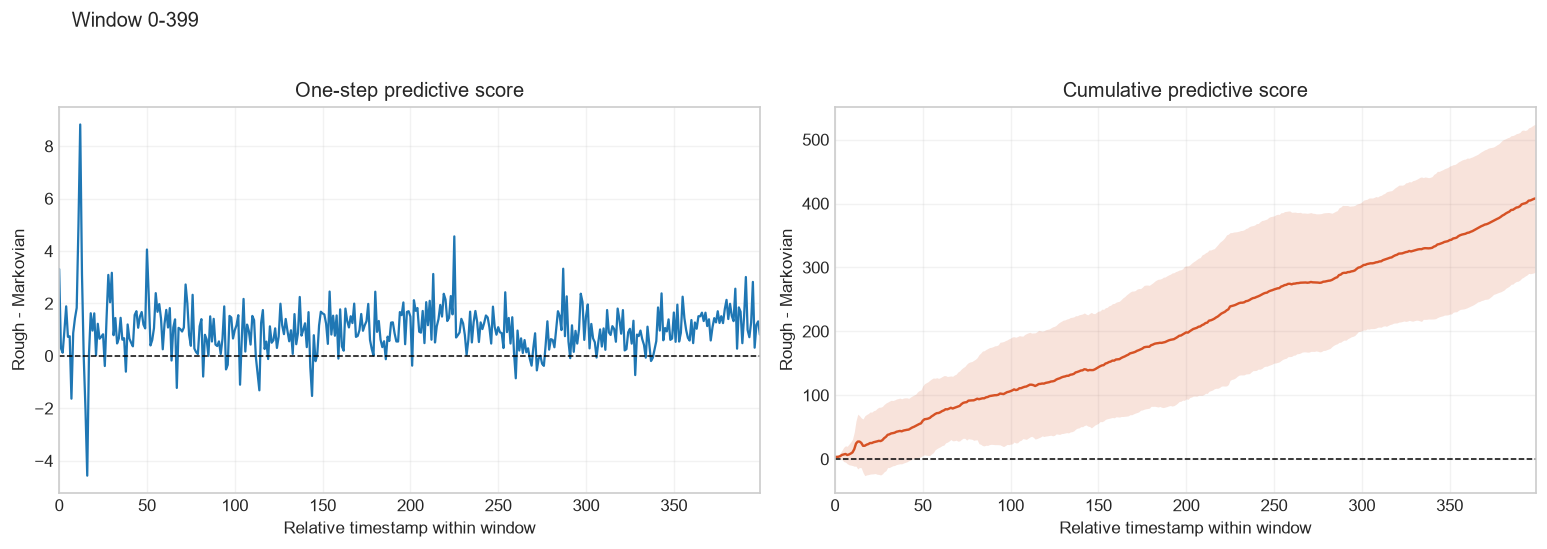

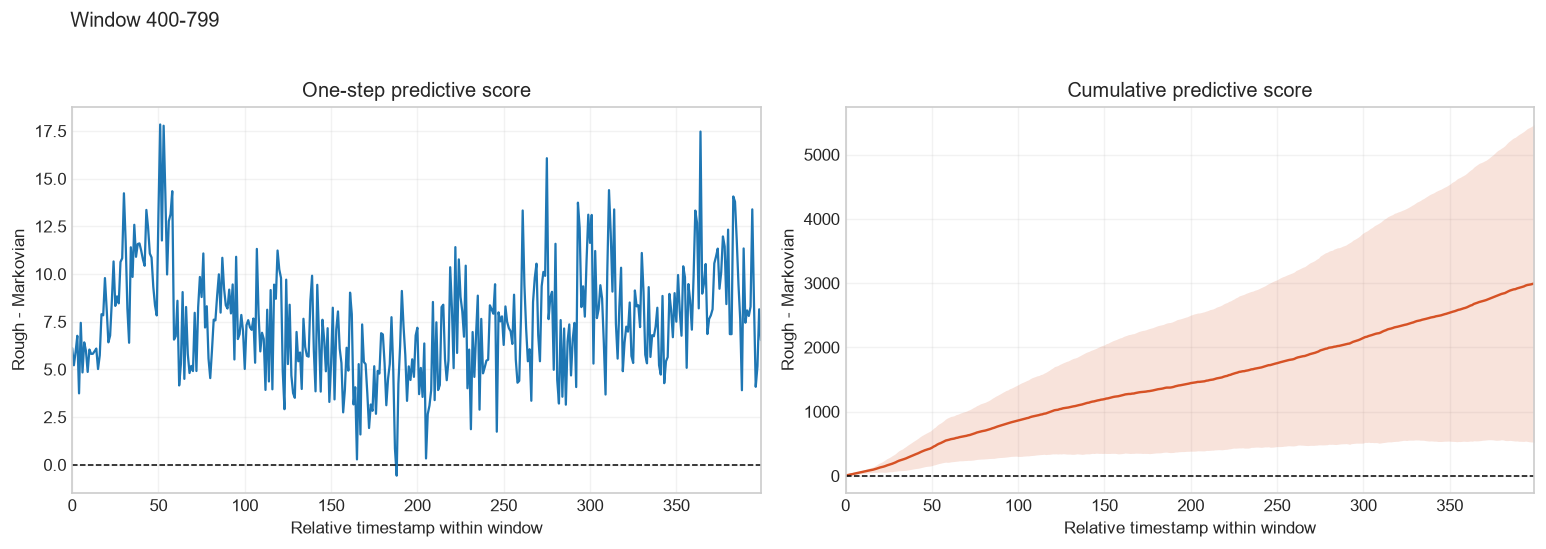

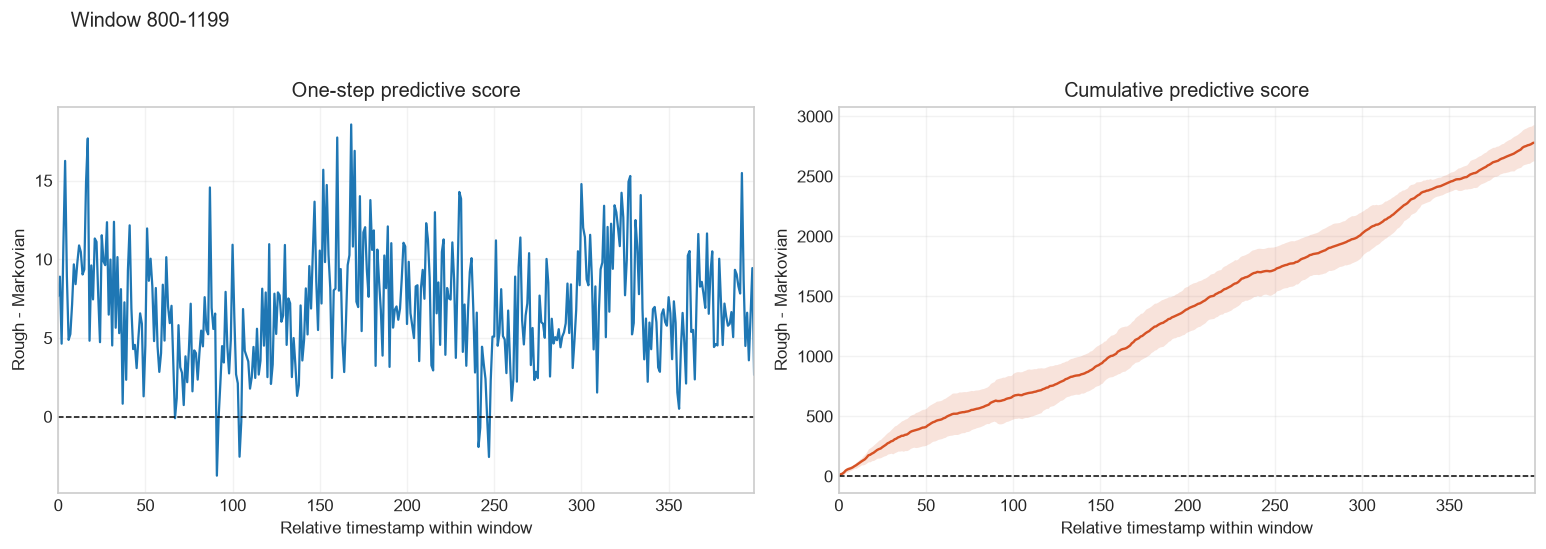

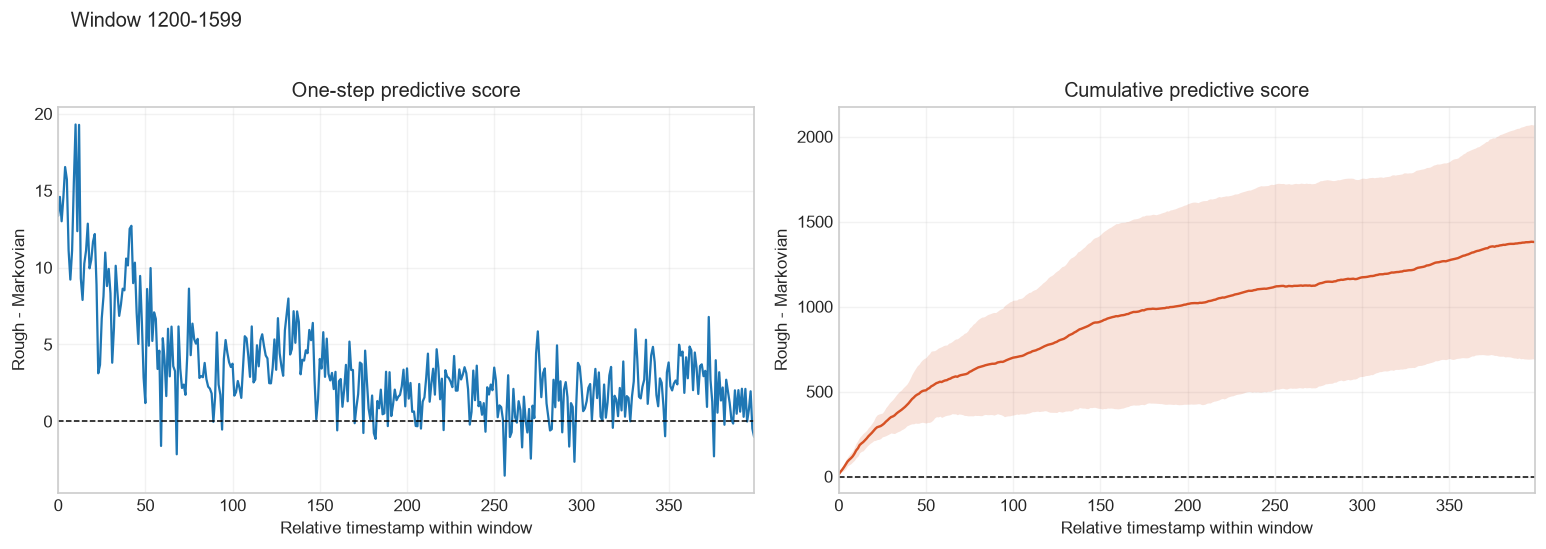

In [7]:
for window_key in WINDOW_ORDER:
    d = timestamp_summary[timestamp_summary["window_key"].eq(window_key)].sort_values("relative_t")
    x = d["relative_t"].to_numpy(dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

    y = d["one_step_difference"].to_numpy(dtype=float)
    axes[0].plot(x, y, color="#1f77b4", linewidth=1.35)
    axes[0].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
    axes[0].set_title("One-step predictive score")
    axes[0].set_xlabel("Relative timestamp within window")
    axes[0].set_ylabel("Rough - Markovian")
    axes[0].set_xlim(0, max(399, float(np.nanmax(x)) if len(x) else 399))
    axes[0].grid(alpha=0.25)

    y = d["cumulative_difference"].to_numpy(dtype=float)
    s = d["cumulative_difference_std"].fillna(0.0).to_numpy(dtype=float)
    axes[1].plot(x, y, color="#d65225", linewidth=1.45)
    axes[1].fill_between(x, y - s, y + s, color="#d65225", alpha=0.16, linewidth=0)
    axes[1].axhline(0.0, color="black", linestyle="--", linewidth=0.9)
    axes[1].set_title("Cumulative predictive score")
    axes[1].set_xlabel("Relative timestamp within window")
    axes[1].set_ylabel("Rough - Markovian")
    axes[1].set_xlim(0, max(399, float(np.nanmax(x)) if len(x) else 399))
    axes[1].grid(alpha=0.25)

    fig.suptitle(f"Window {WINDOW_LABELS[window_key]}", x=0.05, y=1.03, ha="left", fontsize=12)
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / f"predictive_likelihood_score_differences_{window_key}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

## Seed-Level Consistency

This plot shows the final cumulative Rough-SABR minus Markovian score difference for each paired seed.

notebooks\predictive_likelihood.ipynb:40: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  "    here = Path.cwd().resolve() if start is None else Path(start).resolve()\n",


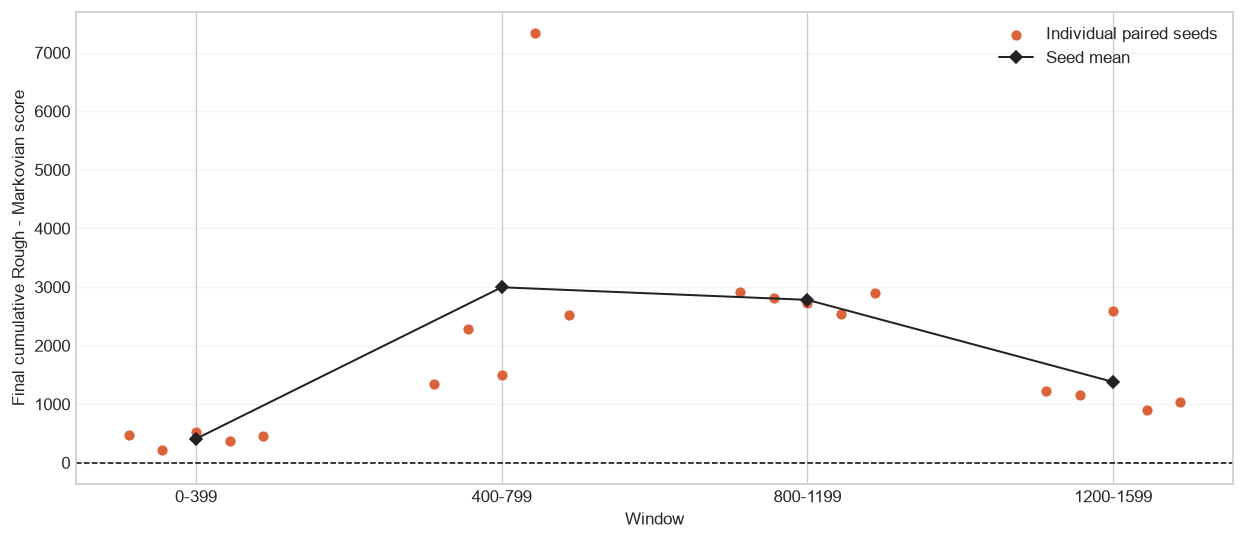

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))

plot_data = seed_summary.copy()
plot_data["window_pos"] = plot_data["window_key"].cat.codes.astype(float)
jitter_lookup = dict(zip(SEEDS, np.linspace(-0.22, 0.22, len(SEEDS))))
plot_data["x"] = plot_data["window_pos"] + plot_data["seed"].map(jitter_lookup)

ax.axhline(0.0, color="black", linestyle="--", linewidth=0.9)
ax.scatter(
    plot_data["x"],
    plot_data["final_cumulative_difference"],
    color="#d65225",
    s=45,
    alpha=0.90,
    edgecolor="white",
    linewidth=0.6,
    label="Individual paired seeds",
)

window_means = seed_summary.groupby("window_key", observed=True)["final_cumulative_difference"].mean().reindex(WINDOW_ORDER)
ax.plot(
    np.arange(len(WINDOW_ORDER)),
    window_means,
    color="#222222",
    marker="D",
    markersize=5,
    linewidth=1.2,
    label="Seed mean",
)

ax.set_xticks(np.arange(len(WINDOW_ORDER)))
ax.set_xticklabels([WINDOW_LABELS[w] for w in WINDOW_ORDER])
ax.set_ylabel("Final cumulative Rough - Markovian score")
ax.set_xlabel("Window")
ax.grid(axis="y", alpha=0.22)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "predictive_likelihood_seed_level_cumulative_differences.png", dpi=220, bbox_inches="tight")
plt.show()